In [388]:
# mount your google drive to load files directly from there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [389]:
# if you want to import Python files, add the correct Google Drive directory to your Pythonpath
import sys
sys.path.append('/content/drive/My Drive/Advanced_deep_learning')

In [390]:
# Download the data from huggingface (https://huggingface.co/datasets/simbaswe/galah4/tree/main)
# and upload it to your google drive. Then, specify this directory here
DATA_PATH = '/content/drive/My Drive/Advanced_deep_learning/Exercise_1'

In [391]:
# import the stuff you need. Pytorch is already installed on Google colab
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
import numpy as np
from matplotlib import pyplot as plt
from torchsummary import summary

In [392]:
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

In [393]:
def normalize(labels, p):
    """
    Normalize the input labels using percentile-based scaling.

    This function scales the input labels to a range of [0, 1] based on the specified percentiles.
    The scaling is done by computing the percentiles of the labels and then normalizing the labels
    using these percentile values. The percentiles are decimals, we use these boundaries as the min/max
    of the dataset could be related to very rare data due to fluctuations, we want to identify a range
    in which are contained most of the data.

    Parameters:
    labels (np.ndarray): The input labels to be normalized.
    p (float): The percentile value used for scaling. The function uses the p-th and (1-p)-th percentiles
               for normalization.

    Returns:
    tuple: A tuple containing the normalized labels and the range used for normalization.
           - normalized_labels (np.ndarray): The normalized labels.
           - ranges (np.ndarray): The range used for normalization, which includes the p-th and (1-p)-th percentiles.
    """
    ranges = np.percentile(labels, [100 * p, 100 * (1 - p)], axis=0)
    labels = (labels - ranges[0]) / (ranges[1] - ranges[0])
    return labels, ranges

In [394]:
# Function to denormalize the labels back to their original scale
def denormalize(labels, ranges):
    """
    Denormalize the input labels using the specified range.

    This function denormalizes the input labels using the specified range values.
    The denormalization is done by scaling the labels back to the original range
    using the provided range values.

    Parameters:
        labels (np.ndarray): The normalized labels to be  denormalized.
        ranges (np.ndarray): The range values used for normalization.

    Returns:
        np.ndarray: The denormalized labels.
    """
    return labels * (ranges[1] - ranges[0]) + ranges[0]


In [395]:
def denormalize_std(uncertainty, ranges):
    """
    Denormalizes the given uncertainty predictions using the provided range.

    It is different to the denormalization of the labels which also includes a shift, as
    the uncertainty is a range and is independent from shifting.

    Parameters
    ----------
    uncertainty : array-like
        The normalized uncertainty to be denormalized.
    ranges : array-like
        A two-element array-like object where the first element is the minimum value
        and the second element is the maximum value of the original range.
    Returns
    -------
    array-like
        The denormalized uncertainty.
    """

    return uncertainty * (ranges[1] - ranges[0])


In [396]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"I'm using: {device}")

I'm using: cuda


**Loading the "Spectra" dataset** $\to$ it contains data from measures of star spectra (features) and variables predictable from them (targets)

In [397]:
spectra = np.load(f"{DATA_PATH}/spectra.npy")
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(f"{DATA_PATH}/labels.npy")
# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]*2 #Double the number of labels as now for each label the model has to predict also the associated gaussian uncertainty

In [398]:
print(f'The "Spectra" dataset contains {spectra.shape[0]} spectra each with {spectra.shape[1]} measures.')
print(f'There are {labels.shape[0]} sets of labels') #Check if there are as many labels as spectra

The "Spectra" dataset contains 8914 spectra each with 16384 measures.
There are 8914 sets of labels


In [399]:
# normalize the spectra: np.maximum forces all the values to be at least 0.2, and then the logarithm of the values is computed.
spectra = np.log(np.maximum(spectra, 0.2))

In [400]:
#percentile normalization of labels: normalization ignoring the 5% lowest data and the 5% highest data. Returns normalized labels and ranges.
labels, range_norm = normalize(labels,0.05)


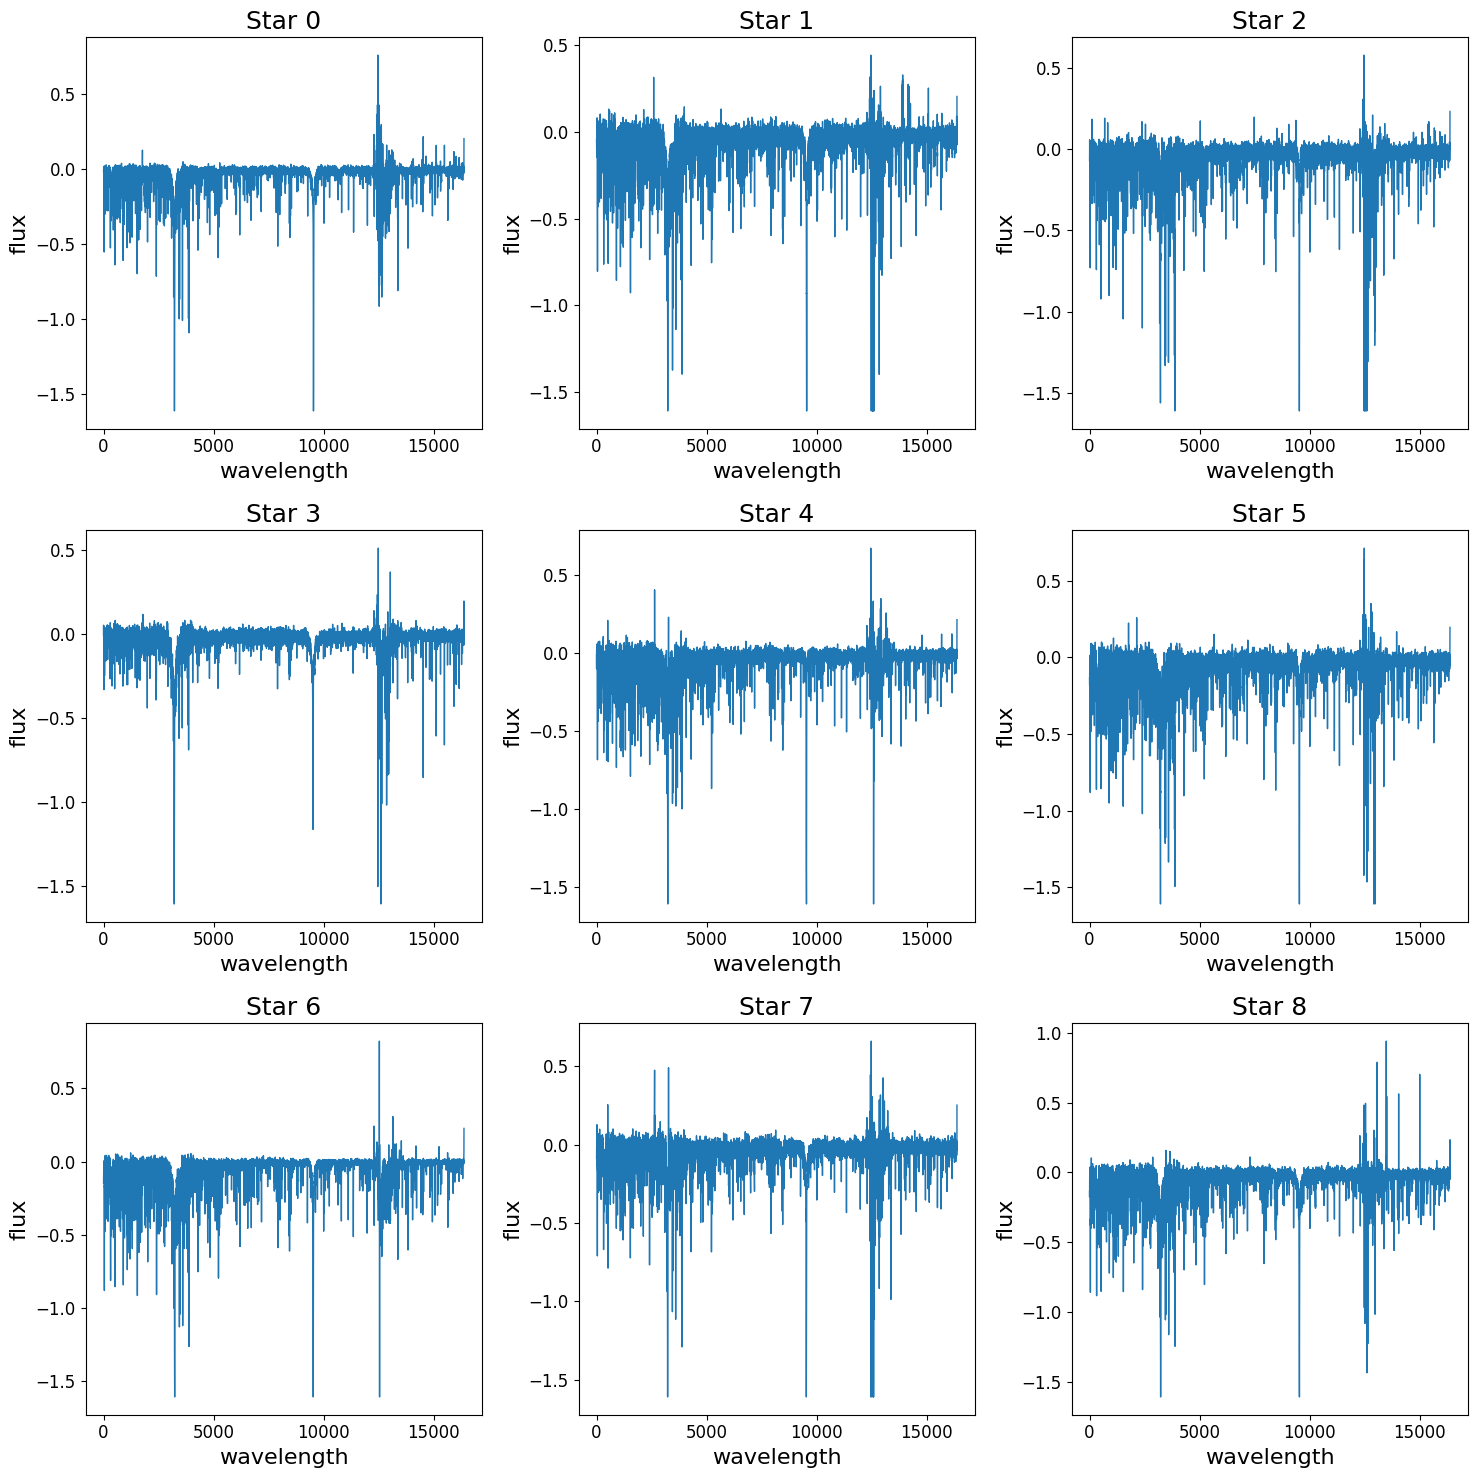

In [401]:
%matplotlib inline

fig, ax = plt.subplots(nrows = 3, ncols=3, figsize=(15, 15))
ax = ax.flatten()

for i in range(9):
  ax[i].set_xlabel('wavelength')
  ax[i].set_ylabel('flux')
  ax[i].plot(spectra[i], lw=1)
  ax[i].set_title(f"Star {i}")
  plt.tight_layout()

**Converting numpay array into PyTorch tensor**

In [402]:
features = torch.from_numpy(spectra)
target = torch.from_numpy(labels)

print(features.device)

cpu


**Implementation of a CustomDataset class** $\to$ this approach allows to manage in a more efficient way the use of the device memory

In [403]:
class CustomDataset(Dataset):
    def __init__(self,X,y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):
        return self.X[idx], self.y[idx]

**Dividing the dataset in train, evaluate and test sets**

In [404]:
dataset = CustomDataset(features, labels)

train_set, eval_set, test_set = random_split(dataset, [0.6, 0.2, 0.2])

In [405]:
batch_size = 128

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
eval_loader = DataLoader(eval_set, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)

**Defining the model**

In [406]:
class TinyCNN(nn.Module):
	def __init__(self, nLabels):
		super(TinyCNN, self).__init__()

		self.model = nn.Sequential(
			nn.Conv1d(1, 10, kernel_size=5), #Starting from 16384 data, default padding is '0': 12 output channels with 16380 data
			nn.ReLU(),
			nn.BatchNorm1d(10),
			nn.Dropout(0.1),
			nn.AvgPool1d(3), #Takes 3 and put the average value in the middle one, 12 output channels with 5460 data

			nn.Conv1d(10, 20, kernel_size=5), #Good procedure to gradually double the number of output channels. 20 output channels with 5456 data.
			nn.ReLU(),
			nn.BatchNorm1d(20),
			nn.Dropout(0.1),
			nn.AvgPool1d(3), #Non divisible by three data number, elements not covered are ignored. 20 output channels with 1818 data.

			nn.Conv1d(20, 40, kernel_size=5), #40 output channels with 1814 data.
			nn.ReLU(),
			nn.BatchNorm1d(40),
			nn.Dropout(0.1),
			nn.AvgPool1d(3), #40 output channels with 604 data.

			nn.Conv1d(40, 10, kernel_size=1), #10 output channels with 604 data.
			nn.ReLU(),
			nn.BatchNorm1d(10),
			nn.Dropout(0.1),
			nn.AvgPool1d(2), #10 output channels with 302 data.

			nn.Conv1d(10, 12, kernel_size=3), #12 output channels with 300 data.
			nn.ReLU(),
			nn.BatchNorm1d(12), #normalizes all the output of the layers to mean 0 and std 1
			nn.Dropout(0.2), #randomly switches off 20% of neurons, in this way there are no predominant neurons on which the network depends strongly

			nn.Conv1d(12, 10, kernel_size=1), #10 output channels with 300 data.
			nn.Dropout(0.2),

			nn.Linear(300, 32), # batch, filters, * -> batch, filters, 32: nn.Linear applies the same linear transformation to all the 10 channels indipendently, I get 10
      #output channels with 32 data each.
			nn.ReLU(),
			nn.Flatten(),
			nn.Linear(10*32, 128),
			nn.ReLU(),
			nn.Linear(128, nLabels) #Now 6 output layers: 3 labels + 3 uncertainties
		)

	def forward(self, x):
		# x = torch.unsqueeze(x,1)
		x = self.model(x)
		return x

In [407]:
# Model selection
model_choice = 'tiny_CNN'

if model_choice == 'tiny_CNN':
    model = TinyCNN(n_labels)
else:
    raise ValueError("Invalid model choice. Please select 'tiny_CNN'.")

model.to(device)

summary(model, input_size=(1, spectra_length))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1            [-1, 10, 16380]              60
              ReLU-2            [-1, 10, 16380]               0
       BatchNorm1d-3            [-1, 10, 16380]              20
           Dropout-4            [-1, 10, 16380]               0
         AvgPool1d-5             [-1, 10, 5460]               0
            Conv1d-6             [-1, 20, 5456]           1,020
              ReLU-7             [-1, 20, 5456]               0
       BatchNorm1d-8             [-1, 20, 5456]              40
           Dropout-9             [-1, 20, 5456]               0
        AvgPool1d-10             [-1, 20, 1818]               0
           Conv1d-11             [-1, 40, 1814]           4,040
             ReLU-12             [-1, 40, 1814]               0
      BatchNorm1d-13             [-1, 40, 1814]              80
          Dropout-14             [-1, 4

Training $\to$ As this is a regression problem with uncertainty estimation, we employ a custom loss function derived from the Maximum Likelihood Estimation (MLE) of a Gaussian distribution. For each sample, the model predicts the parameters of a Gaussian distribution: the mean ($\mu$) represents the predicted value, while the standard deviation ($\sigma$) quantifies the uncertainty. The loss function aims to maximize the likelihood of observing the targets given these predicted distributions.

In [408]:
N_epochs = 50
learning_rate = 0.005

In [409]:
def loss_likelihood(output, label, n_labels):
  mean = output[:,:n_labels] #The predicted values correspond to the first half of the output values of the model
  log_std = output[:,n_labels:] #The predicted logarithms of the gaussian uncertainties are the second half of the output values of the model
  std = torch.exp(log_std) #Convertion of the logarithms of the uncertainties into the uncertainties
  return torch.mean((0.5*((label-mean)/std)**2)+log_std) #Likelihood problem solution, considered loss function, average on the three labels

In [410]:
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [411]:
train_loss = []
eval_loss = []

#-------Training-------
for epoch in range(N_epochs):
  start_time = time.time()  # Start the timer for this epoch

  model.train()
  loss_val = []

  for step,(feature, label) in enumerate(train_loader):
    feature = feature.unsqueeze(1).float().to(device) #put data on GPU
    label = label.float().to(device)
    output = model(feature) #model prediction, add the channel dimension so the model doesn't confuse it with the batch size
    loss = loss_likelihood(output, label,3) #loss computation
    loss_val.append(loss.item())

    optimizer.zero_grad() #clean the gradients computed at previous iteration
    loss.backward() #backpropagation
    optimizer.step() #weights update

     # Print progress every 10th step, updating the same line
    if (step + 1) % 10 == 0:
      sys.stdout.write(f"\rEpoch [{epoch + 1}/{N_epochs}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
      sys.stdout.flush()

  sys.stdout.write("\n")  # Move to the next line after the epoch
  train_loss.append(np.mean(loss_val)) # store mean loss of each epoch

#---------------------
#-------Validation-------
  with torch.no_grad():
    model.eval()
    loss_val = []
    for feature, label in eval_loader:
      feature = feature.unsqueeze(1).float().to(device)
      label = label.float().to(device)
      output = model(feature)
      loss = loss_likelihood(output,label,3)
      loss_val.append(loss.item())

    eval_loss.append(np.mean(loss_val))

#------------------------



Epoch [1/50], Step [40/42], Loss: -0.9608
Epoch [2/50], Step [40/42], Loss: -1.4038
Epoch [3/50], Step [40/42], Loss: -1.5178
Epoch [4/50], Step [40/42], Loss: -1.4504
Epoch [5/50], Step [40/42], Loss: -1.7607
Epoch [6/50], Step [40/42], Loss: -1.4239
Epoch [7/50], Step [40/42], Loss: -1.5208
Epoch [8/50], Step [40/42], Loss: -1.8926
Epoch [9/50], Step [40/42], Loss: -1.6629
Epoch [10/50], Step [40/42], Loss: -2.0145
Epoch [11/50], Step [40/42], Loss: -1.8516
Epoch [12/50], Step [40/42], Loss: -1.9541
Epoch [13/50], Step [40/42], Loss: -1.7037
Epoch [14/50], Step [40/42], Loss: -1.8389
Epoch [15/50], Step [40/42], Loss: -1.8705
Epoch [16/50], Step [40/42], Loss: -1.7250
Epoch [17/50], Step [40/42], Loss: -2.0624
Epoch [18/50], Step [40/42], Loss: -2.0659
Epoch [19/50], Step [40/42], Loss: -2.1542
Epoch [20/50], Step [40/42], Loss: -2.0966
Epoch [21/50], Step [40/42], Loss: -2.1051
Epoch [22/50], Step [40/42], Loss: -1.3892
Epoch [23/50], Step [40/42], Loss: -1.9913
Epoch [24/50], Step 

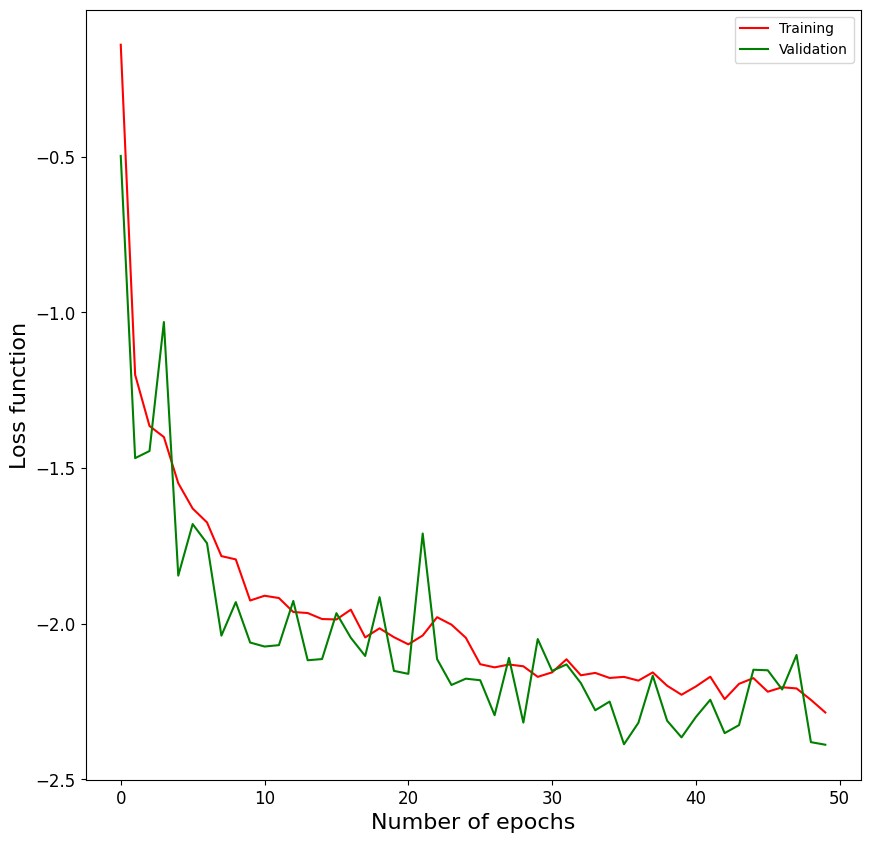

In [412]:
plt.figure(figsize = (10,10))
plt.xlabel('Number of epochs')
plt.ylabel('Loss function')
plt.plot(range(N_epochs), train_loss, color = 'red', label = 'Training')
plt.plot(range(N_epochs), eval_loss, color = 'green', label = 'Validation')
plt.legend(fontsize = 10)
plt.show()

In [413]:
predictions = []
targets = []
test_loss = []

with torch.no_grad():
  model.eval()
  for feature,label in test_loader:
    feature = feature.unsqueeze(1).float().to(device)
    label = label.float().to(device)
    output = model(feature)
    loss = loss_likelihood(output,label,3)
    test_loss.append(loss.item())

    predictions.append(output.cpu())
    targets.append(label.cpu())

pred = torch.cat(predictions, dim=0).numpy()
real = torch.cat(targets, dim=0).numpy()

avrg_test_loss = np.mean(test_loss)

print(f'Average test loss: {avrg_test_loss:.4f}')

Average test loss: -2.3983


In [414]:
denorm_predictions = denormalize(pred[:,:3], range_norm)  # Denormalize predictions
denorm_std = denormalize_std(np.exp(pred[:,3:]), range_norm) #Denormalize standard deviation, as the model predicts the logarithm to get the std the exponential must be computed
denorm_true_labels = denormalize(real, range_norm)  # Denormalize true labels

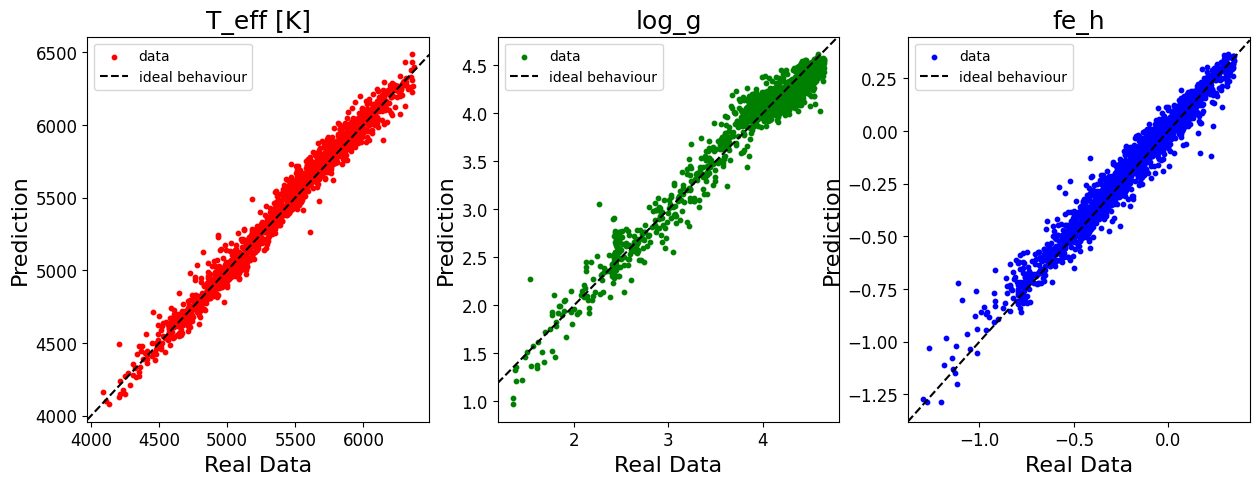

In [415]:
fig,ax = plt.subplots(nrows = 1, ncols = 3, figsize = (15,5))
ax = ax.flatten()

ax[0].set_xlabel('Real Data')
ax[0].set_ylabel('Prediction')
ax[0].set_title('T_eff [K]')
ax[0].scatter(denorm_true_labels[:,0],denorm_predictions[:,0], color = 'red', s = 10, label = 'data')
ax[0].axline((denorm_true_labels[:,0].min(), denorm_true_labels[:,0].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[0].legend(fontsize = 10)

ax[1].set_xlabel('Real Data')
ax[1].set_ylabel('Prediction')
ax[1].set_title('log_g')
ax[1].scatter(denorm_true_labels[:,1],denorm_predictions[:,1], color = 'green', s = 10, label = 'data')
ax[1].axline((denorm_true_labels[:,1].min(), denorm_true_labels[:,1].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[1].legend(fontsize = 10)


ax[2].set_xlabel('Real Data')
ax[2].set_ylabel('Prediction')
ax[2].set_title('fe_h')
ax[2].scatter(denorm_true_labels[:,2],denorm_predictions[:,2], color = 'blue', s = 10, label = 'data')
ax[2].axline((denorm_true_labels[:,2].min(), denorm_true_labels[:,2].min()), slope=1, color='black', linestyle='--', label = 'ideal behaviour')
ax[2].legend(fontsize = 10)

plt.show()



**Uncertainty validity check** $\to$ to check the validity of the obtained uncertainties, a possibility is to visualize the **"Pull Distribution** $$\frac{\mu_{pred}-label}{\sigma_{pred}}$$. Well-predicted uncertainties should be associated to a gaussian with mean zero and standard deviation 1.

In [416]:
pull_val = (denorm_predictions - denorm_true_labels)/denorm_std

In [417]:
counts_1, bin_edges_1 = np.histogram(pull_val[:,0], bins=50, density=True) #Obtain counts for the bins and bin limits for the gaussian fits of the histograms
counts_2, bin_edges_2 = np.histogram(pull_val[:,1], bins=50, density=True)
counts_3, bin_edges_3 = np.histogram(pull_val[:,2], bins=50, density=True)

In [418]:
from scipy.stats import norm

mu_1, std_1 = norm.fit(pull_val[:,0]) #Built in function for gaussian fit of data, computes their mean and standard deviation
mu_2, std_2 = norm.fit(pull_val[:,1])
mu_3, std_3 = norm.fit(pull_val[:,2])

x_range_1 = np.linspace(bin_edges_1[0], bin_edges_1[-1], 100) #Define an arbitrary x_range to plot the fitted curve
curve_fit_1 = norm.pdf(x_range_1, mu_1, std_1) #Define points distributed on the computed gaussian for the defined range

x_range_2 = np.linspace(bin_edges_2[0], bin_edges_2[-1], 100) #Define an arbitrary x_range to plot the fitted curve
curve_fit_2 = norm.pdf(x_range_2, mu_2, std_2) #Define points distributed on the computed gaussian for the defined range

x_range_3 = np.linspace(bin_edges_3[0], bin_edges_3[-1], 100) #Define an arbitrary x_range to plot the fitted curve
curve_fit_3 = norm.pdf(x_range_3, mu_3, std_3) #Define points distributed on the computed gaussian for the defined range


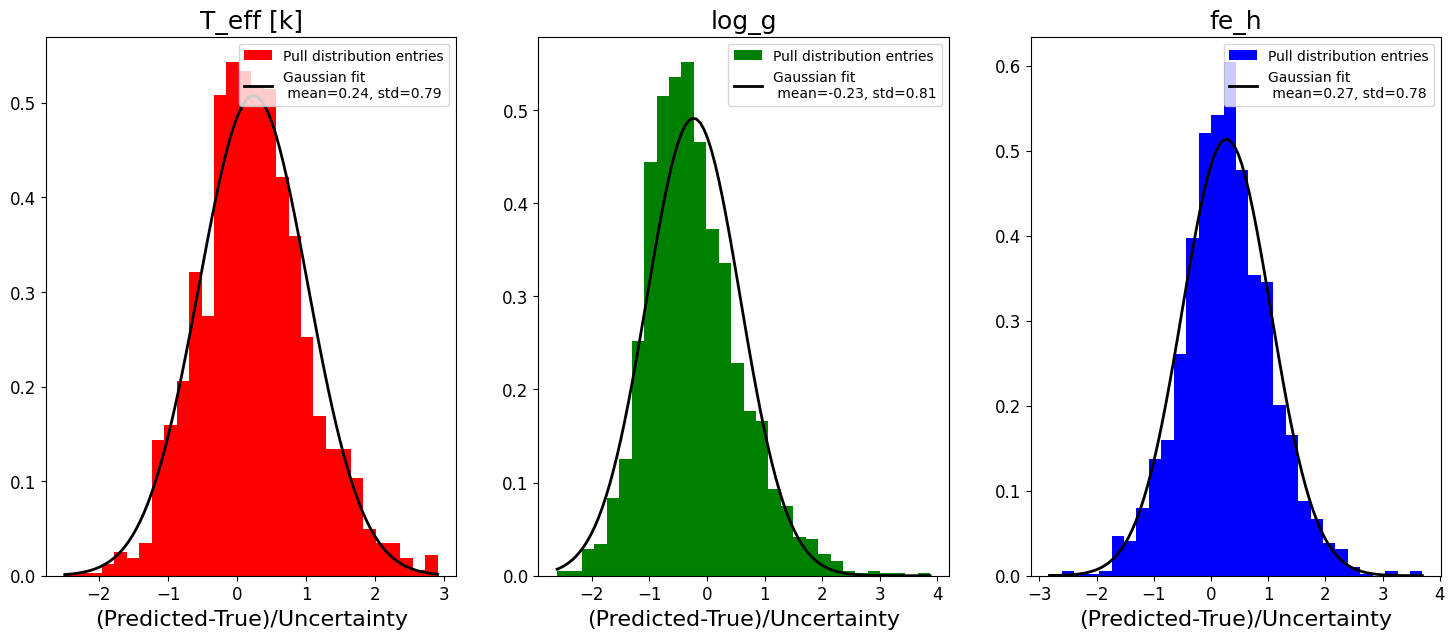

In [419]:
fig,ax = plt.subplots(nrows = 1, ncols = 3, figsize = (18,7))
ax = ax.flatten()

ax[0].hist(pull_val[:,0], bins=30, density=True, color='red', label = 'Pull distribution entries')
ax[0].plot(x_range_1, curve_fit_1, 'black', lw=2, label=f'Gaussian fit\n mean={mu_1:.2f}, std={std_1:.2f}')
ax[0].set_title('T_eff [k]')
ax[0].set_xlabel('(Predicted-True)/Uncertainty')
ax[0].legend(fontsize = 10)

ax[1].hist(pull_val[:,1], bins=30, density=True, color='green', label = 'Pull distribution entries')
ax[1].plot(x_range_2, curve_fit_2, 'black', lw=2, label=f'Gaussian fit\n mean={mu_2:.2f}, std={std_2:.2f}')
ax[1].set_title('log_g')
ax[1].set_xlabel('(Predicted-True)/Uncertainty')
ax[1].legend(fontsize = 10)

ax[2].hist(pull_val[:,2], bins=30, density=True, color='blue', label = 'Pull distribution entries')
ax[2].plot(x_range_3, curve_fit_3, 'black', lw=2, label=f'Gaussian fit\n mean={mu_3:.2f}, std={std_3:.2f}')
ax[2].set_title('fe_h')
ax[2].set_xlabel('(Predicted-True)/Uncertainty')
ax[2].legend(fontsize = 10)

plt.show()